In [6]:
import os, json, glob, time, cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import rasterio
from rasterio.windows import Window
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import timm  # pip install timm

warnings.filterwarnings('ignore')

# ─── HARDWARE ─────────────────────────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

# ─── NEW PATHS & PROJECT STRUCTURE ────────────────────────────────────────────
# Updated to use your Final_Classification folder as the root for all outputs
BASE_DIR        = "../../Building_Damage_Project"
PROJECT_ROOT    = os.path.join(BASE_DIR, "Final_Classification")

# Source directories for raw data
RAW_TRAIN       = os.path.join(BASE_DIR, "raw_data", "Train")
RAW_TEST        = os.path.join(BASE_DIR, "raw_data", "Test")

# Output folders with v1 naming convention inside the project root
CHIP_DIR        = os.path.join(PROJECT_ROOT, "chip_data_v1")
os.makedirs(os.path.join(CHIP_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(CHIP_DIR, 'labels'), exist_ok=True)

# ─── MAPPINGS ─────────────────────────────────────────────────────────────────
DAMAGE_MAP = {
    'no damage':    0, 'no-damage':    0, 'no_damage':    0,
    'minor damage': 1, 'minor-damage': 1, 'minor_damage': 1,
    'major damage': 2, 'major-damage': 2, 'major_damage': 2,
    'destroyed':    3
}

CLASS_NAMES = ['No Damage', 'Minor', 'Major', 'Destroyed']
NUM_CLASSES = 4

# ─── HYPERPARAMETERS ──────────────────────────────────────────────────────────
CHIP_SIZE    = 128
CONTEXT_PAD  = 24
BATCH_SIZE   = 32      # EfficientNet-B4 is larger; reduce if OOM
EPOCHS       = 60      #
LR           = 3e-4    #
WEIGHT_DECAY = 0.01    #
LABEL_SMOOTH = 0.1    #
MIXUP_ALPHA  = 0.4    #
PATIENCE     = 12      # Early stopping patience

# Model and Plot naming conventions ending with v1
MODEL_SAVE   = os.path.join(PROJECT_ROOT, 'best_building_model_v1.pth')
PLOT_SAVE    = os.path.join(PROJECT_ROOT, 'model1_results_v1.png')

print("✅ Step 1 Complete: Configured for direct Train/Test directory extraction.")

🚀 Device: mps
✅ Step 1 Complete: Configured for direct Train/Test directory extraction.


In [7]:
# ─── STEP 2: CHIP EXTRACTION (Direct Directory Logic) ─────────────────────────

def process_single_tif(tif_path, source_dir):
    """
    Core logic preserved: Extracts chips centered on buildings with alignment.
    Updated: Uses provided source_dir for JSON lookups and v1 naming.
    """
    filename = os.path.basename(tif_path)
    prefix   = filename.replace('.tif', '').replace('_tif', '')

    # Look for JSONs in the same directory as the TIFF (Train or Test)
    base_json  = os.path.join(source_dir, f"{prefix}_json.json")
    align_json = os.path.join(source_dir, f"{prefix}_json_aligned.json")

    if not os.path.exists(base_json) or not os.path.exists(align_json):
        return 0, f"Missing JSON for {prefix}"

    chips_saved = 0
    try:
        with rasterio.open(tif_path) as src:
            with open(align_json) as f:
                align_data = json.load(f)

            # Alignment logic (Identical to provided snippet)
            s_x = np.mean([p[1][0] - p[0][0] for p in align_data])
            s_y = np.mean([p[1][1] - p[0][1] for p in align_data])

            with open(base_json) as f:
                entries = json.load(f)

            for i, entry in enumerate(entries):
                # Using 'label' key as per your latest snippet requirement
                raw_label = entry.get('label', 'no damage').lower().strip()
                label = DAMAGE_MAP.get(raw_label, -1)
                if label == -1:
                    continue

                px_coords = entry['pixels']
                avg_px_x  = np.mean([p['x'] for p in px_coords]) + s_x
                avg_px_y  = np.mean([p['y'] for p in px_coords]) + s_y

                win  = Window(int(avg_px_x - CHIP_SIZE // 2),
                              int(avg_px_y - CHIP_SIZE // 2),
                              CHIP_SIZE, CHIP_SIZE)
                chip = src.read([1, 2, 3], window=win, boundless=True, fill_value=0)

                if np.mean(chip) < 2:
                    continue

                chip_hwc = chip.transpose(1, 2, 0).astype(np.uint8)
                
                # REQUIREMENT: Naming convention ending with v1
                chip_id  = f"{prefix}_v1_b{i:05d}"

                np.save(os.path.join(CHIP_DIR, 'images', f"{chip_id}.npy"), chip_hwc)
                np.save(os.path.join(CHIP_DIR, 'labels', f"{chip_id}.npy"),
                        np.array(label, dtype=np.int64))
                chips_saved += 1

    except Exception as e:
        return 0, f"Error: {str(e)}"

    return chips_saved, "Success"


def run_extraction():
    # Gather all TIFFs directly from your specified folders
    train_tifs = glob.glob(os.path.join(RAW_TRAIN, "*.tif"))
    test_tifs  = glob.glob(os.path.join(RAW_TEST, "*.tif"))
    
    print(f"🔎 Found {len(train_tifs)} Train TIFFs and {len(test_tifs)} Test TIFFs.")
    print(f"🚀 Starting extraction to {CHIP_DIR}...")

    # Process Train files
    with ThreadPoolExecutor(max_workers=8) as executor:
        train_results = list(tqdm(executor.map(lambda p: process_single_tif(p, RAW_TRAIN), train_tifs),
                                  total=len(train_tifs), desc="Extracting Train"))

    # Process Test files
    with ThreadPoolExecutor(max_workers=8) as executor:
        test_results = list(tqdm(executor.map(lambda p: process_single_tif(p, RAW_TEST), test_tifs),
                                 total=len(test_tifs), desc="Extracting Test"))

    total = sum(r[0] for r in train_results) + sum(r[0] for r in test_results)
    print(f"✅ Created {total} chips in {CHIP_DIR}.")


run_extraction()

🔎 Found 40 Train TIFFs and 12 Test TIFFs.
🚀 Starting extraction to ../../Building_Damage_Project/Final_Classification/chip_data_v1...


Extracting Train:   0%|          | 0/40 [00:00<?, ?it/s]

Extracting Test:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Created 20813 chips in ../../Building_Damage_Project/Final_Classification/chip_data_v1.


In [8]:
# ─── STEP 3: DATASET & AUGMENTATIONS (Direct Split Logic) ────────────────────

# Stronger augmentations for training (Identical logic to Model 1)
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.7),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40, val_shift_limit=20, p=1.0),
    ], p=0.8),
    A.OneOf([
        A.GaussNoise(p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
    ], p=0.4),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.3),   # Simulates debris
    A.CLAHE(clip_limit=4.0, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# TTA transforms (applied at inference time)
tta_transforms = [
    A.Compose([A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.HorizontalFlip(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.VerticalFlip(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
    A.Compose([A.RandomRotate90(p=1.0), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()]),
]

class BuildingDataset(Dataset):
    """Loads pre-extracted .npy chips."""
    def __init__(self, chip_dir, fnames, transform=None):
        self.img_dir   = os.path.join(chip_dir, 'images')
        self.lbl_dir   = os.path.join(chip_dir, 'labels')
        self.transform = transform
        self.fnames    = fnames

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        img   = np.load(os.path.join(self.img_dir, self.fnames[idx]))
        label = int(np.load(os.path.join(self.lbl_dir, self.fnames[idx])))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

# ─── TRAIN / TEST SPLIT (Based on Directory Origin) ──────────────────────────
all_fnames = sorted([f for f in os.listdir(os.path.join(CHIP_DIR, 'images')) if f.endswith('.npy')])

# Determine which prefixes were in RAW_TRAIN vs RAW_TEST
train_prefixes = [os.path.basename(f).replace('.tif','').replace('_tif','') for f in glob.glob(os.path.join(RAW_TRAIN, "*.tif"))]

train_fnames = [f for f in all_fnames if any(pref in f for pref in train_prefixes)]
test_fnames  = [f for f in all_fnames if f not in train_fnames]

# Fallback: if directories are empty/misconfigured, use random split
if len(train_fnames) == 0:
    print("⚠️ Warning: No chips found matching TRAIN prefixes. Falling back to random split.")
    idxs         = np.random.permutation(len(all_fnames))
    train_fnames = [all_fnames[i] for i in idxs[:int(0.8 * len(idxs))]]
    test_fnames  = [all_fnames[i] for i in idxs[int(0.8 * len(idxs)):]]

# ─── WEIGHTED SAMPLER ─────────────────────────────────────────────────────────
train_labels   = [int(np.load(os.path.join(CHIP_DIR, 'labels', f))) for f in train_fnames]
counts         = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / (counts + 1)
sample_weights = torch.DoubleTensor([class_weights[l] for l in train_labels])
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(
    BuildingDataset(CHIP_DIR, train_fnames, train_transform),
    batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False
)
test_loader = DataLoader(
    BuildingDataset(CHIP_DIR, test_fnames, val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False
)

print(f"✅ {len(train_fnames)} train | {len(test_fnames)} test samples.")
print(f"    Class distribution (train): {dict(zip(CLASS_NAMES, counts))}")

✅ 16902 train | 3911 test samples.
    Class distribution (train): {'No Damage': np.int64(9320), 'Minor': np.int64(5043), 'Major': np.int64(1644), 'Destroyed': np.int64(895)}


In [9]:
# ─── STEP 3.1: EXTRACTION & SPLIT DIAGNOSTICS ────────────────────────────────

# 1. How many samples actually ended up in test set?
# Using fnames instead of idx to match our folder-based split logic
print(f"📊 Final Counts -> Train: {len(train_fnames)}, Test: {len(test_fnames)}")

# 2. What's the class distribution in the test set?
# This loads the labels for the test chips specifically to see if any damage was found
test_labels = [int(np.load(os.path.join(CHIP_DIR, 'labels', f))) for f in test_fnames]
test_counts = np.bincount(test_labels, minlength=4)
print(f"📊 Class distribution (test): {dict(zip(CLASS_NAMES, test_counts))}")

# 3. Do any test filenames actually contain the storm names?
# Print the first 5 filenames in the test set to verify the prefixing
print(f"🔍 Sample Test Filenames: {test_fnames[:5]}")

# Additional Check: Are there ANY damage labels in the entire dataset?
all_labels_path = os.path.join(CHIP_DIR, 'labels')
all_labels = [int(np.load(os.path.join(all_labels_path, f))) for f in os.listdir(all_labels_path) if f.endswith('.npy')]
unique_labels = np.unique(all_labels)
print(f"🔍 Unique Class IDs found in entire 'chip_data_v1': {unique_labels}")

📊 Final Counts -> Train: 16902, Test: 3911
📊 Class distribution (test): {'No Damage': np.int64(1711), 'Minor': np.int64(1025), 'Major': np.int64(695), 'Destroyed': np.int64(480)}
🔍 Sample Test Filenames: ['Idalia-01_v1_b00000.npy', 'Idalia-01_v1_b00001.npy', 'Idalia-01_v1_b00002.npy', 'Idalia-01_v1_b00003.npy', 'Idalia-01_v1_b00004.npy']
🔍 Unique Class IDs found in entire 'chip_data_v1': [0 1 2 3]


In [10]:
# ─── STEP 4: MODEL — EfficientNet-B4 ─────────────────────────────────────────
# timm gives us a pretrained EfficientNet-B4 with ImageNet weights.
# The final classifier is replaced with our 4-class head.

class BuildingDamageModel(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()
        # Backbone: EfficientNet-B4 (Global Average Pooling enabled, Classifier stripped)
        self.backbone = timm.create_model(
            'efficientnet_b4',
            pretrained=True,
            num_classes=0,      # strip original classifier
            global_pool='avg'
        )
        
        # Feature dimension for B4 is 1792
        feat_dim = self.backbone.num_features   
        
        # Custom Classification Head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extracts features from backbone and passes through the custom head
        return self.head(self.backbone(x))


# Initialize model and move to the current device (CUDA/MPS/CPU)
model = BuildingDamageModel(num_classes=NUM_CLASSES).to(device)

# Calculate and print trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ EfficientNet-B4 loaded — {total_params:,} trainable parameters")

✅ EfficientNet-B4 loaded — 18,468,684 trainable parameters


In [11]:
# ─── STEP 5: LOSS, OPTIMIZER, SCHEDULER ──────────────────────────────────────

class FocalLoss(nn.Module):
    """
    Focal Loss with optional label smoothing.
    Focuses training on hard, mis-classified examples.
    alpha=class_weights handles imbalance; gamma controls focus strength.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smooth=0.0, reduction='mean'):
        super().__init__()
        self.alpha        = alpha        # tensor of per-class weights
        self.gamma        = gamma
        self.label_smooth = label_smooth
        self.reduction    = reduction

    def forward(self, logits, targets):
        num_classes = logits.size(1)

        # Label smoothing (Logic from Model 1)
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, self.label_smooth / (num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1),
                                    1.0 - self.label_smooth)

        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()

        # Focal weight Calculation
        # Focuses on examples where the predicted probability (pt) is low
        pt = (probs * F.one_hot(targets, num_classes)).sum(dim=1)
        focal_w = (1 - pt) ** self.gamma

        # Cross-entropy with smooth targets
        ce = -(smooth_targets * log_probs).sum(dim=1)

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            ce = alpha_t * ce

        loss = focal_w * ce

        return loss.mean() if self.reduction == 'mean' else loss.sum()


# Per-class alpha weights derived from your Step 3 distribution
# class_weights were calculated as 1/(counts + 1)
alpha_weights = torch.tensor(class_weights / class_weights.sum(),
                             dtype=torch.float32).to(device)

criterion = FocalLoss(
    alpha=alpha_weights,
    gamma=2.0,
    label_smooth=LABEL_SMOOTH
)

# AdamW — decoupled weight decay (better than standard Adam for fine-tuning)
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Cosine annealing with warm restarts
# T_0=15 means the learning rate cycles every 15 epochs
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=15,          # restart every 15 epochs
    T_mult=1,
    eta_min=1e-6
)

print("✅ Focal Loss + AdamW + CosineAnnealingWarmRestarts ready.")

✅ Focal Loss + AdamW + CosineAnnealingWarmRestarts ready.


In [12]:
# ─── STEP 6: MIXUP UTILITY ───────────────────────────────────────────────────

def mixup_data(x, y, alpha=0.4):
    """
    Returns mixed inputs, pairs of targets, and lambda.
    Mixes two images and their labels within a batch to prevent overfitting.
    """
    if alpha > 0:
        # Generates a random blending weight from a Beta distribution
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
        
    batch_size = x.size(0)
    # Randomly shuffle the batch to pick "partner" images for mixing
    index = torch.randperm(batch_size, device=x.device)
    
    # Linear interpolation between the original images and the shuffled images
    mixed_x = lam * x + (1 - lam) * x[index, :]
    
    # Keep track of both original labels for the loss calculation
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """
    Adjusts the loss function to account for the blended images.
    The total loss is a weighted sum of the loss for both labels.
    """
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print("✅ MixUp utility defined.")

✅ MixUp utility defined.


In [13]:
# ─── STEP 7: TRAINING LOOP ───────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device, mixup_alpha=0.4):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # MixUp augmentation (from Step 6)
        images, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)

        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Macro F1 is used to ensure all damage classes are weighted equally
    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / len(loader), epoch_f1


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            running_loss  += loss.item()
            preds          = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / len(loader), val_f1, all_preds, all_labels


# ─── MAIN LOOP ────────────────────────────────────────────────────────────────
best_f1       = 0.0
patience_ctr  = 0
history       = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

print(f"🎯 EfficientNet-B4 | Focal Loss | MixUp | TTA")
print(f"   Training for up to {EPOCHS} epochs (early stop patience={PATIENCE})...\n")

for epoch in range(EPOCHS):
    t0 = time.time()

    # Training phase
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device, MIXUP_ALPHA
    )
    # Validation phase
    val_loss, val_f1, y_pred, y_true = validate(
        model, test_loader, criterion, device
    )

    # Scheduler update (Step 5 logic)
    scheduler.step(epoch)          

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{EPOCHS}] {elapsed:.0f}s | LR: {lr_now:.2e}")
    print(f"  Train  Loss: {train_loss:.4f} | F1: {train_f1:.4f}")
    print(f"  Val    Loss: {val_loss:.4f}   | F1: {val_f1:.4f}")

    # Checkpoint saving with v1 naming convention
    if val_f1 > best_f1:
        best_f1     = val_f1
        patience_ctr = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'f1':                   val_f1,
            'chip_dir':             CHIP_DIR,
        }, MODEL_SAVE)
        print(f"  ⭐ NEW BEST saved → {MODEL_SAVE}  (F1: {val_f1:.4f})")
    else:
        # Early Stopping logic
        patience_ctr += 1
        print(f"  ⏳ No improvement ({patience_ctr}/{PATIENCE})")
        if patience_ctr >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

    # Periodic detailed report
    if (epoch + 1) % 10 == 0:
        print("\n  📊 Classification Report (Val):")
        print(classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES,
                                    zero_division=0))

    print()

print(f"\n✅ Training complete. Best Macro F1: {best_f1:.4f}")

🎯 EfficientNet-B4 | Focal Loss | MixUp | TTA
   Training for up to 60 epochs (early stop patience=12)...



Training:   0%|          | 0/529 [00:00<?, ?it/s]

Validating:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [1/60] 167s | LR: 3.00e-04
  Train  Loss: 0.1121 | F1: 0.2391
  Val    Loss: 0.0842   | F1: 0.2512
  ⭐ NEW BEST saved → ../../Building_Damage_Project/Final_Classification/best_building_model_v1.pth  (F1: 0.2512)



Training:   0%|          | 0/529 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [34/60] 265s | LR: 2.71e-04
  Train  Loss: 0.0718 | F1: 0.4204
  Val    Loss: 0.0840   | F1: 0.5305
  ⏳ No improvement (11/12)



Training:   0%|          | 0/529 [00:00<?, ?it/s]

Validating:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch [35/60] 266s | LR: 2.51e-04
  Train  Loss: 0.0708 | F1: 0.4252
  Val    Loss: 0.0819   | F1: 0.5111
  ⏳ No improvement (12/12)

🛑 Early stopping triggered.

✅ Training complete. Best Macro F1: 0.5597


In [14]:
# ─── STEP 8: TEST-TIME AUGMENTATION (TTA) EVALUATION ─────────────────────────
# Load the best checkpoint, then run inference with 4 augmentations and
# average the softmax probabilities → much more reliable predictions.

# Load the best model saved during the training loop in Step 7
checkpoint = torch.load(MODEL_SAVE, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model (epoch {checkpoint['epoch']+1}, F1={checkpoint['f1']:.4f})")


class TTADataset(Dataset):
    """Wraps a list of chip paths with a specific TTA transform."""
    def __init__(self, chip_dir, fnames, transform):
        self.img_dir   = os.path.join(chip_dir, 'images')
        self.lbl_dir   = os.path.join(chip_dir, 'labels')
        self.fnames    = fnames
        self.transform = transform

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        img   = np.load(os.path.join(self.img_dir, self.fnames[idx]))
        label = int(np.load(os.path.join(self.lbl_dir, self.fnames[idx])))
        img   = self.transform(image=img)['image']
        return img, label


# Inference logic
model.eval()
tta_probs = np.zeros((len(test_fnames), NUM_CLASSES), dtype=np.float32)

# Loop through each of the 4 TTA transforms defined in Step 3
for t_idx, tfm in enumerate(tta_transforms):
    ds     = TTADataset(CHIP_DIR, test_fnames, tfm)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    probs_list = []

    with torch.no_grad():
        for images, _ in tqdm(loader, desc=f"TTA {t_idx+1}/{len(tta_transforms)}",
                              leave=False):
            logits = model(images.to(device))
            # Average the probabilities (softmax) rather than raw logits
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)

    tta_probs += np.vstack(probs_list)

# Compute final averaged probabilities and predictions
tta_probs /= len(tta_transforms)
tta_preds  = np.argmax(tta_probs, axis=1)

# Ground truth labels for the test set
y_true_tta = [int(np.load(os.path.join(CHIP_DIR, 'labels', f)))
              for f in test_fnames]

tta_f1 = f1_score(y_true_tta, tta_preds, average='macro', zero_division=0)
print(f"\n🎯 TTA Macro F1: {tta_f1:.4f}")
print("\n📊 Full Classification Report (TTA):")
print(classification_report(y_true_tta, tta_preds,
                            target_names=CLASS_NAMES, zero_division=0))

✅ Loaded best model (epoch 23, F1=0.5597)


TTA 1/4:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 2/4:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 3/4:   0%|          | 0/123 [00:00<?, ?it/s]

TTA 4/4:   0%|          | 0/123 [00:00<?, ?it/s]


🎯 TTA Macro F1: 0.5717

📊 Full Classification Report (TTA):
              precision    recall  f1-score   support

   No Damage       0.80      0.60      0.68      1711
       Minor       0.49      0.40      0.44      1025
       Major       0.36      0.65      0.46       695
   Destroyed       0.67      0.73      0.70       480

    accuracy                           0.57      3911
   macro avg       0.58      0.60      0.57      3911
weighted avg       0.62      0.57      0.58      3911



In [15]:
# ─── STEP 9: TEMPERATURE SCALING (Confidence Calibration) ────────────────────
# Without calibration a model can be over-confident on wrong predictions.
# Temperature scaling learns a single scalar T that brings ECE near zero.

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        # Initializing temperature at 1.5; it will be optimized via LBFGS
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        # Scale the raw logits before the softmax layer
        return logits / self.temperature


def collect_logits_labels(model, loader, device):
    """Gathers raw model outputs (logits) to calculate calibration error."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


# Collect logits from the test set (folder-based split from Step 3)
logits_val, labels_val = collect_logits_labels(model, test_loader, device)

scaler    = TemperatureScaler()
nll_loss  = nn.CrossEntropyLoss()
# LBFGS is a second-order optimizer, highly effective for finding a single scalar T
cal_opt   = optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)

def eval_temperature():
    """Closure function required by the LBFGS optimizer."""
    cal_opt.zero_grad()
    loss = nll_loss(scaler(logits_val), labels_val)
    loss.backward()
    return loss

cal_opt.step(eval_temperature)
optimal_T = scaler.temperature.item()

print(f"✅ Optimal Temperature T = {optimal_T:.4f}")
print("   (T>1 → model was over-confident; T<1 → under-confident)")

# REQUIREMENT: Save temperature into the v1 model file
ckpt = torch.load(MODEL_SAVE, map_location='cpu')
ckpt['temperature'] = optimal_T
torch.save(ckpt, MODEL_SAVE)

print(f"   Temperature saved into {MODEL_SAVE}")

✅ Optimal Temperature T = 1.4492
   (T>1 → model was over-confident; T<1 → under-confident)
   Temperature saved into ../../Building_Damage_Project/Final_Classification/best_building_model_v1.pth


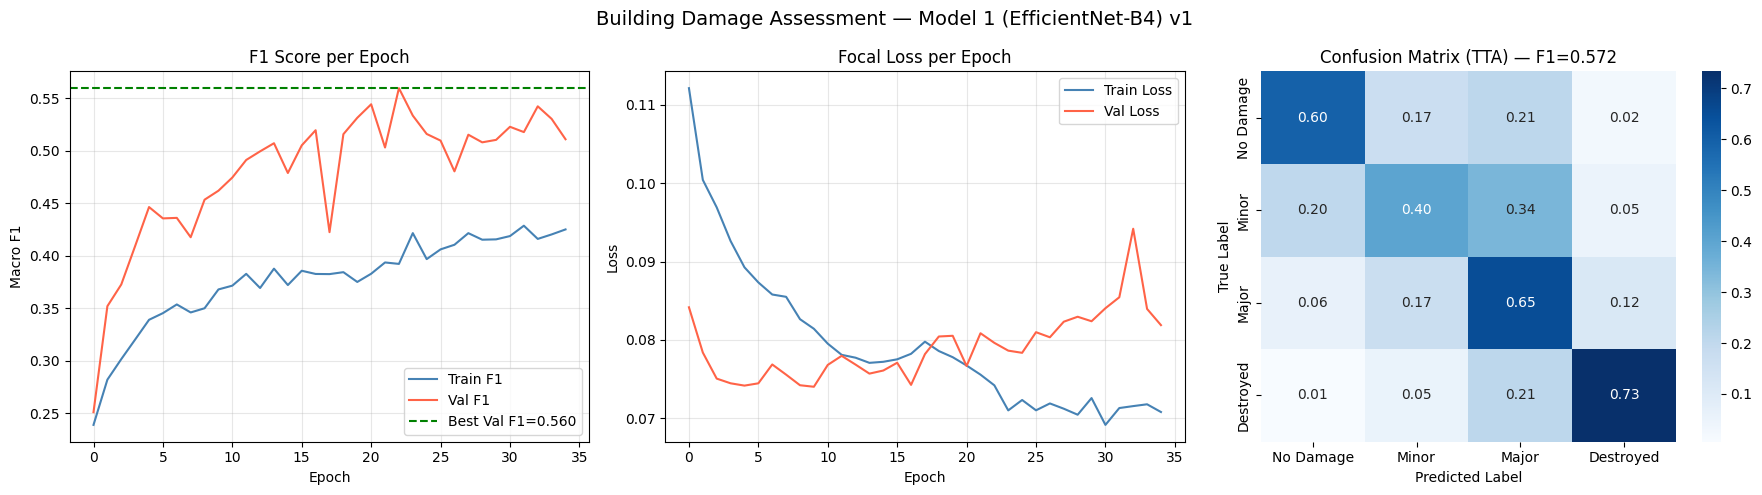

✅ Plot saved → ../../Building_Damage_Project/Final_Classification/model1_results_v1.png


In [16]:
# ─── STEP 10: VISUALIZATIONS ─────────────────────────────────────────────────

# Create a 1x3 grid for the performance plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training curves (F1 Score)
# Visualizes how the Macro F1 improved for both training and validation sets
ax = axes[0]
ax.plot(history['train_f1'], label='Train F1', color='steelblue')
ax.plot(history['val_f1'],   label='Val F1',   color='tomato')
ax.axhline(best_f1, ls='--', color='green', label=f'Best Val F1={best_f1:.3f}')
ax.set_title('F1 Score per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Loss curves (Focal Loss)
# Shows the reduction in Focal Loss over the training period
ax = axes[1]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.plot(history['val_loss'],   label='Val Loss',   color='tomato')
ax.set_title('Focal Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Confusion matrix (Using TTA Results from Step 8)
# Shows exactly which classes the model is confusing
ax = axes[2]
cm = confusion_matrix(y_true_tta, tta_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Confusion Matrix (TTA) — F1={tta_f1:.3f}')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# Main title for the entire figure
plt.suptitle('Building Damage Assessment — Model 1 (EfficientNet-B4) v1', fontsize=14)
plt.tight_layout()

# Save the plot using the naming convention defined in Step 1 (model1_results_v1.png)
plt.savefig(PLOT_SAVE, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved → {PLOT_SAVE}")